In [2]:
from qiskit import *
from qiskit_aer import *

In [3]:
def return_maj():
    maj = QuantumCircuit(3, name = "MAJ");
    maj.cx(2, 1); maj.cx(2, 0); maj.ccx(0, 1, 2);
    return maj.to_gate();

In [4]:
def return_uma():
    uma = QuantumCircuit(3, name = "UMA");
    uma.ccx(0, 1, 2); uma.cx(2, 0); uma.cx(0, 1);
    return uma.to_gate();

In [5]:
maj = return_maj(); uma = return_uma();

In [6]:
def create_n_bit_subtractor(n: int, inv_x: str, inv_y: str, maj, uma):
    qc = QuantumCircuit(2 * n + 2); # One for the initial carry bit, other for the overflow sum
    cr_sum = ClassicalRegister(n, name = 'sum');
    cr_overflow = ClassicalRegister(1, name = 'overflow');
    qc.add_register(cr_sum); qc.add_register(cr_overflow);
    if inv_x: # if it is not empty
        for i, ch in enumerate(inv_x):
            qc.x(2 * i + 1);
            if ch == '1':
                qc.x(2 * i + 1)
    if inv_y:
        for i, ch in enumerate(inv_y):
            if ch == '1':
                qc.x(2 * i + 2);
    
    for i in range(2, 2 * n + 1, 2):
        qc.append(maj, [i - 2, i - 1, i]);
        
    qc.barrier();
    
    qc.cx(2 * n, 2 * n + 1);
    
    for i in range(2 * n, 0, -2):
        qc.append(uma, [i - 2, i - 1, i]);
        qc.x(i - 1);

    for i in range(n):
        qc.measure(2 * i + 1, cr_sum[i]);
    qc.measure(2 * n + 1, cr_overflow[0]);
    return qc

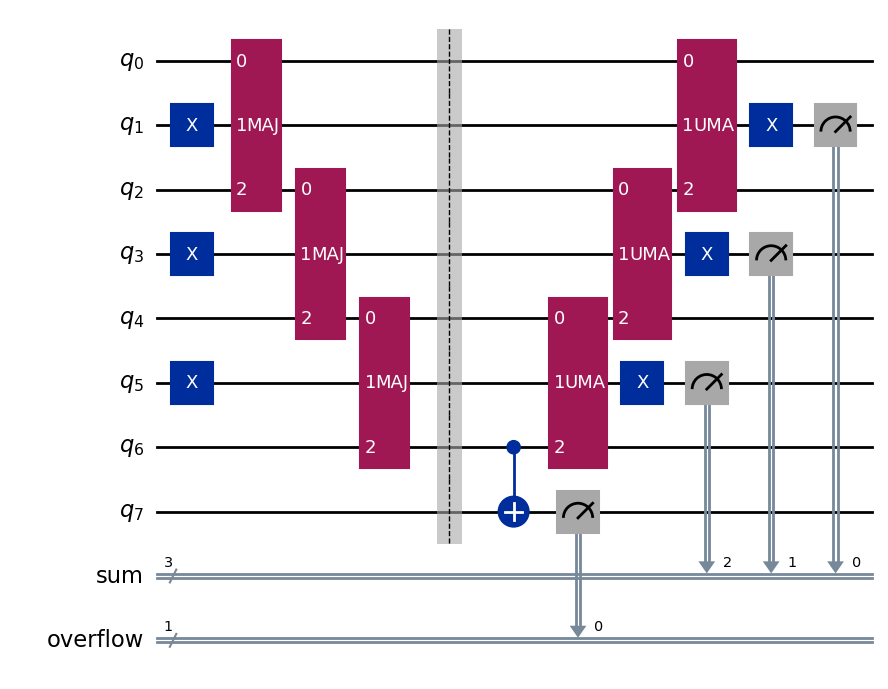

In [9]:
qc = create_n_bit_subtractor(3, "000"[::-1], "000"[::-1], maj, uma);
qc.draw('mpl')

In [8]:
sim = AerSimulator(method = 'statevector');
cc = transpile(qc, sim);

In [30]:
res = sim.run(cc).result()
counts = res.get_counts(cc)
counts

{'0 1000': 1024}